# University of London - ML Code - Computer Science Final Project

**BSc Computer Science**

**Subject: CM3070 Computer Science Final Project**

**Student: In Final Project report**

**Student Number: In Final Project report**

## Experiment 14

Summary: Based on the results of experimentFour, experimentTen, experimentEleven, experimentTwelve, and experimentThirteen, this experiment seeks to see if there is a performance gains from the 10 days sequence length to 10 days future prediction, is based on a 1:1 ratio that can be translated to predictions further into the future. The amount of days for this experiment will be 20 days.

Important differences:
- Use a sequence length of 20 days
- Use a delay of 20 days
- Use 10 number of solutions
- Use 4 num_parents_mating
- Use 600 generations

## Preparing the data

### Transforming the csv data to a numpy array

In [1]:
import numpy as np

str_to_np_date = lambda x: np.datetime64(x)

usdYen_raw_data = np.genfromtxt("./data/currency-data/USD-JPY-DAILY.csv", skip_header=1, delimiter=";", usecols=1)
usdYen_raw_data_dates = np.genfromtxt("./data/currency-data/USD-JPY-DAILY.csv", skip_header=1, delimiter=";", usecols=0, converters={0: str_to_np_date})

print("Length: ",len(usdYen_raw_data))
print("Data type: ",usdYen_raw_data.dtype)
print("Raw Data: ",usdYen_raw_data)
print("Raw Data Dates: ",usdYen_raw_data_dates)

Length:  5000
Data type:  float64
Raw Data:  [154.71 155.21 155.81 ... 118.22 118.89 118.46]
Raw Data Dates:  ['2025-12-16' '2025-12-15' '2025-12-12' ... '2006-10-19' '2006-10-18'
 '2006-10-17']


As the currency data is from newer to older, the order should be inverted.

In [2]:
usdYen_raw_data = np.flip(usdYen_raw_data, axis=0)
print(usdYen_raw_data)

[118.46 118.89 118.22 ... 155.81 155.21 154.71]


### Computing the numer of samples for each data split

In [3]:
train_samples_number = len(usdYen_raw_data)
print("Number of train samples: ", train_samples_number)

Number of train samples:  5000


### Creating timeseries data

Based on the code provided in Chapter 10 (Deep Learning For Timeseries) of the book Deep Learning with Python by Francois Chollet [1].

In [4]:
from tensorflow import keras

# Parameters
sampling_rate = 1
sequence_length = 20 # Observations will go back 20 days
delay = sampling_rate * (sequence_length + 20 - 1) # target is 20 days after the end of the sequence
batch_size = train_samples_number

# train dataset
train_dataset = keras.utils.timeseries_dataset_from_array(
    usdYen_raw_data[:-delay],
    targets=usdYen_raw_data[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    batch_size=batch_size,
)

### - Checking that timeseries data works correctly

Based on the code provided in Chapter 10 (Deep Learning For Timeseries) of the book Deep Learning with Python by Francois Chollet [1].

In [5]:
for inputs, targets in train_dataset:
    for i in range(inputs.shape[0]):
        print([float(x) for x in inputs[i]], float(targets[i]))

[118.46, 118.89, 118.22, 118.7, 119.34, 119.42, 119.01, 118.41, 117.6, 117.46, 116.96, 117.04, 117.15, 118.0, 118.28, 117.67, 117.85, 117.9, 117.54, 118.15] 116.97
[118.89, 118.22, 118.7, 119.34, 119.42, 119.01, 118.41, 117.6, 117.46, 116.96, 117.04, 117.15, 118.0, 118.28, 117.67, 117.85, 117.9, 117.54, 118.15, 117.6] 116.76
[118.22, 118.7, 119.34, 119.42, 119.01, 118.41, 117.6, 117.46, 116.96, 117.04, 117.15, 118.0, 118.28, 117.67, 117.85, 117.9, 117.54, 118.15, 117.6, 118.01] 117.56
[118.7, 119.34, 119.42, 119.01, 118.41, 117.6, 117.46, 116.96, 117.04, 117.15, 118.0, 118.28, 117.67, 117.85, 117.9, 117.54, 118.15, 117.6, 118.01, 118.21] 117.83
[119.34, 119.42, 119.01, 118.41, 117.6, 117.46, 116.96, 117.04, 117.15, 118.0, 118.28, 117.67, 117.85, 117.9, 117.54, 118.15, 117.6, 118.01, 118.21, 117.74] 118.16
[119.42, 119.01, 118.41, 117.6, 117.46, 116.96, 117.04, 117.15, 118.0, 118.28, 117.67, 117.85, 117.9, 117.54, 118.15, 117.6, 118.01, 118.21, 117.74, 118.02] 118.13
[119.01, 118.41, 11

2026-01-15 01:19:53.661095: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### - Extracting data inputs and outputs

Based on the code provided in Chapter 10 (Deep Learning For Timeseries) of the book Deep Learning with Python by Francois Chollet [1].

In [6]:
import tensorflow as tf

data_inputs = []
data_outputs = []

for samples, targets in train_dataset:
    print("Samples: ", samples)
    print("Sample shape: ", samples.shape)
    print("Targets: ", targets)
    print("Targets shape: ", targets.shape)
    data_inputs = tf.make_ndarray(tf.make_tensor_proto(samples))
    data_outputs = tf.reshape(tf.make_ndarray(tf.make_tensor_proto(targets)), [-1,1])

data_inputs_test = data_inputs[-200:]
data_outputs_test = data_outputs[-200:]
data_inputs = data_inputs[:-200]
data_outputs = data_outputs[:-200]

print("Data Inputs: ", len(data_inputs))
print("Data Inputs Test: ", len(data_inputs_test))
print("Data Outputs: ", len(data_outputs))
print("Data Outputs Test: ", len(data_outputs_test))
    

Samples:  tf.Tensor(
[[118.46 118.89 118.22 ... 117.9  117.54 118.15]
 [118.89 118.22 118.7  ... 117.54 118.15 117.6 ]
 [118.22 118.7  119.34 ... 118.15 117.6  118.01]
 ...
 [147.62 148.9  149.79 ... 150.42 150.62 150.74]
 [148.9  149.79 149.49 ... 150.62 150.74 151.93]
 [149.79 149.49 148.58 ... 150.74 151.93 151.97]], shape=(4942, 20), dtype=float64)
Sample shape:  (4942, 20)
Targets:  tf.Tensor([116.97 116.76 117.56 ... 155.24 155.5  157.15], shape=(4942,), dtype=float64)
Targets shape:  (4942,)
Data Inputs:  4742
Data Inputs Test:  200
Data Outputs:  4742
Data Outputs Test:  200


2026-01-15 01:19:53.839571: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [7]:
print("----")
print("Input Data: ", data_inputs)
print("----")
print("Output Data: ", data_outputs)
print("----")

----
Input Data:  [[118.46  118.89  118.22  ... 117.9   117.54  118.15 ]
 [118.89  118.22  118.7   ... 117.54  118.15  117.6  ]
 [118.22  118.7   119.34  ... 118.15  117.6   118.01 ]
 ...
 [153.412 154.815 157.417 ... 158.109 157.657 157.459]
 [154.815 157.417 156.407 ... 157.657 157.459 157.948]
 [157.417 156.407 157.096 ... 157.459 157.948 156.435]]
----
Output Data:  tf.Tensor(
[[116.97 ]
 [116.76 ]
 [117.56 ]
 ...
 [151.988]
 [152.47 ]
 [154.401]], shape=(4742, 1), dtype=float64)
----


## Simple LSTM Model

In [8]:
from keras import models
from keras import layers
from keras import activations

def build_lstm_model():
    model = models.Sequential()
    model.add(layers.LSTM(16, input_shape=(sequence_length, 1)))
    model.add(layers.Dense(8, activation=activations.linear))
    model.add(layers.Dense(4, activation=activations.linear))
    model.add(layers.Dense(1, activation=activations.linear))
    model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
    model.summary()
    return model

prototype_model = build_lstm_model()

/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329 (5.19 KB)

 Trainable params: 1,329 (5.19 KB)

 Non-trainable params: 0 (0.00 B)

## Genetic Algorithm

The code for the Genetic Algorithm is based on the code provided by the PyGAD library documentation [2].

### - Instance of the pygad.kerasga.KerasGA class

In [9]:
import pygad.kerasga

keras_ga = pygad.kerasga.KerasGA(model=prototype_model, num_solutions=10)

### - Fitness function

In [10]:
def fitness_function(ga_instance, solution, solution_index):
    global data_inputs, data_outputs, keras_ga, prototype_model
    predictions = pygad.kerasga.predict(model=prototype_model, solution=solution, data=data_inputs)
    mae = keras.losses.MeanAbsoluteError()
    absolute_error = mae(data_outputs, predictions).numpy() + 0.00000001
    solution_fitness = 20 / absolute_error
    return solution_fitness

### - Track GA

In [11]:
def on_generation(ga_instance):
    print(f"Generation = {ga_instance.generations_completed}")
    print(f"Fitness    = {ga_instance.best_solution()[1]}")

### - Create instance of the pygad.GA class

In [12]:
num_generations = 400
num_parents_mating = 4
initial_population = keras_ga.population_weights

ga_instance = pygad.GA(
                        num_generations=num_generations,
                        num_parents_mating=num_parents_mating,
                        initial_population=initial_population,
                        fitness_func=fitness_function,
                        on_generation=on_generation,
                        suppress_warnings=True,
                        parallel_processing=["thread", 4],
                        mutation_type="adaptive",
                        mutation_percent_genes=[12,6]
                       )

In [13]:
ga_instance.summary()

----------------------------------------------------------------------
                           PyGAD Lifecycle                           
Step                  Handler                          Output Shape
Fitness Function      fitness_function()               (1)         
----------------------------------------------------------------------
Parent Selection      steady_state_selection()         (4, 1329)   
Number of Parents: 4
----------------------------------------------------------------------
Crossover             single_point_crossover()         (4, 1329)   
----------------------------------------------------------------------
Mutation              adaptive_mutation()              (4, 1329)   
Mutation Genes: [159  79]
Random Mutation Range: (-1.0, 1.0)
Mutation by Replacement: False
Allow Duplicated Genes: True
----------------------------------------------------------------------
On Generation         on_generation()                  None        
-------------------------

"----------------------------------------------------------------------\n                           PyGAD Lifecycle                           \n======================================================================\nStep                  Handler                          Output Shape\n======================================================================\nFitness Function      fitness_function()               (1)         \n----------------------------------------------------------------------\nParent Selection      steady_state_selection()         (4, 1329)   \nNumber of Parents: 4\n----------------------------------------------------------------------\nCrossover             single_point_crossover()         (4, 1329)   \n----------------------------------------------------------------------\nMutation              adaptive_mutation()              (4, 1329)   \nMutation Genes: [159  79]\nRandom Mutation Range: (-1.0, 1.0)\nMutation by Replacement: False\nAllow Duplicated Genes: True\n----

In [14]:
ga_instance.run()

Generation = 1
Fitness    = 0.19184322655200958
Generation = 2
Fitness    = 0.19622530043125153
Generation = 3
Fitness    = 0.19622530043125153
Generation = 4
Fitness    = 0.20675738155841827
Generation = 5
Fitness    = 0.21367372572422028
Generation = 6
Fitness    = 0.2310139685869217
Generation = 7
Fitness    = 0.23439203202724457
Generation = 8
Fitness    = 0.24139586091041565
Generation = 9
Fitness    = 0.26485759019851685
Generation = 10
Fitness    = 0.27861422300338745
Generation = 11
Fitness    = 0.28996020555496216
Generation = 12
Fitness    = 0.30703461170196533
Generation = 13
Fitness    = 0.3573398292064667
Generation = 14
Fitness    = 0.3765418231487274
Generation = 15
Fitness    = 0.3977377414703369
Generation = 16
Fitness    = 0.399213582277298
Generation = 17
Fitness    = 0.4373858869075775
Generation = 18
Fitness    = 0.6363619565963745
Generation = 19
Fitness    = 0.7445128560066223
Generation = 20
Fitness    = 1.4030507802963257
Generation = 21
Fitness    = 1.40305078

/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/pygad/visualize/plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


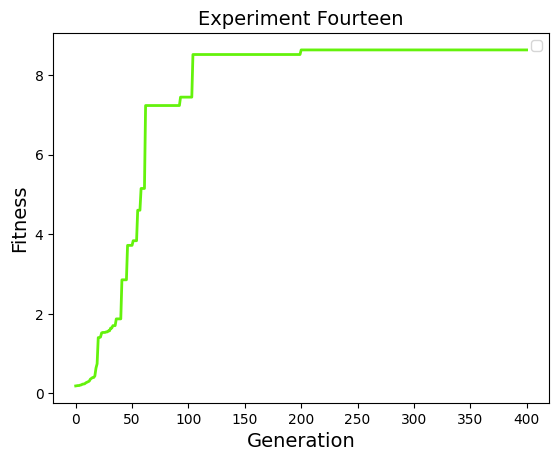

Figure(640x480)


In [15]:
print(ga_instance.plot_fitness(title=f"Experiment Fourteen", linewidth=2))

### - Run best solution

In [16]:
solution, solution_fitness, solution_index = ga_instance.best_solution()
predictions = pygad.kerasga.predict(model=prototype_model, solution=solution,data=data_inputs)
mae = keras.losses.MeanAbsoluteError()
absolute_error = mae(data_outputs, predictions).numpy()
print("Solution fitness: ", solution_fitness, " (20 is the best)")
print("Predictions: ", predictions)
print("Absolute Error: ", absolute_error)

Solution fitness:  8.637203  (20 is the best)
Predictions:  [[118.793686]
 [118.036835]
 [118.6199  ]
 ...
 [154.92351 ]
 [154.9743  ]
 [154.82458 ]]
Absolute Error:  2.3155644


### - Save Genetic Algorithm and export ML model

**Save Genetic Algorithm**

In [17]:
ga_instance.save(filename="genetic-algorithms/genetic_algorithm_experiment_fourteen")

**Export model (keras and tensorflow)**

In [18]:
# Get the best solution as a keras weight matrix
ga_best_solution_weights = pygad.kerasga.model_weights_as_matrix(model=prototype_model, weights_vector=solution)

# Set the weights
prototype_model.set_weights(ga_best_solution_weights)

In [19]:
# Save the model (for Keras)
prototype_model.save("models/experiment_fourteen_prototype_model.keras")

# Save the model (for Tensorflow)
prototype_model.export("models/experiment_fourteen_prototype_model_tf", format="tf_saved_model")

INFO:tensorflow:Assets written to: models/experiment_fourteen_prototype_model_tf/assets


INFO:tensorflow:Assets written to: models/experiment_fourteen_prototype_model_tf/assets


Saved artifact at 'models/experiment_fourteen_prototype_model_tf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 20, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  5650687248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5650686096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5650684560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5650687440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5650688784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5650688400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5650689360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5650689168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5650689744: TensorSpec(shape=(), dtype=tf.resource, name=None)


## Prediction using loaded model

### - Load model and make a prediction

Load the model

In [20]:
from keras.models import load_model

loaded_model = load_model("models/experiment_fourteen_prototype_model.keras")

/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 11 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Make a prediction

In [21]:
keras_predictions_loaded_model = loaded_model.predict(data_inputs)
mae_loaded_model = keras.losses.MeanAbsoluteError()
absolute_error_loaded_model = mae(data_outputs, keras_predictions_loaded_model).numpy()
print("Predictions (loaded_model): ", keras_predictions_loaded_model)
print("Absolute Error (loaded_model): ", absolute_error_loaded_model)

149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Predictions (loaded_model):  [[118.793686]
 [118.036835]
 [118.6199  ]
 ...
 [154.92351 ]
 [154.9743  ]
 [154.82458 ]]
Absolute Error (loaded_model):  2.3155644


Same Absolute Error as the best solution of the Genetic Algorithm. This means that the model was saved correctly.

### - Test loaded model using test data

Using test_data check the MAE of the model. This data has not been used before, and thus works as a good way of measuring the performance of the model.

In [22]:
keras_predictions_loaded_model_with_test_data = loaded_model.predict(data_inputs_test)
absolute_error_loaded_model_with_test_data = mae(data_outputs_test, keras_predictions_loaded_model_with_test_data).numpy()
print("Predictions (loaded_model with test data): ", keras_predictions_loaded_model_with_test_data)
print("Absolute Error (loaded_model): ", absolute_error_loaded_model_with_test_data)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predictions (loaded_model with test data):  [[154.66277]
 [154.7606 ]
 [154.69048]
 [154.63113]
 [154.75859]
 [154.71819]
 [154.69598]
 [154.52791]
 [154.60211]
 [154.56303]
 [154.43825]
 [154.50061]
 [154.43025]
 [154.35144]
 [154.09871]
 [153.8424 ]
 [153.72078]
 [153.68573]
 [153.66277]
 [153.868  ]
 [153.64467]
 [153.47658]
 [153.25407]
 [153.20134]
 [153.01132]
 [152.54646]
 [152.20111]
 [151.99374]
 [151.61705]
 [151.33554]
 [151.25768]
 [151.32121]
 [151.05072]
 [150.99185]
 [150.6834 ]
 [150.24931]
 [149.97124]
 [149.47629]
 [149.31717]
 [149.32082]
 [149.13036]
 [149.30963]
 [149.54848]
 [149.70985]
 [149.6869 ]
 [149.69112]
 [149.8607 ]
 [150.35968]
 [150.39696]
 [150.65123]
 [150.94252]
 [150.8138 ]
 [150.82512]
 [150.7625 ]
 [150.47902]
 [149.51158]
 [149.22768]
 [149.18582]
 [148.59499]
 [148.61745]
 [147.48674]
 [146.40472]
 [145.45518]
 [144.95007]
 [143.87946]
 [143.7061 ]
 [143.42511]
 [142.53369]
 [143.1355 ]
 [143.65446]
 [143.633

Visualize predicted values

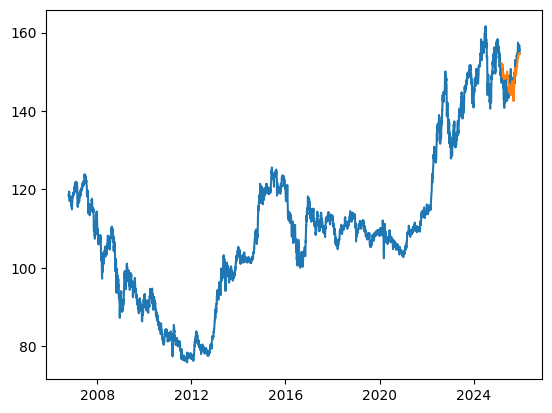

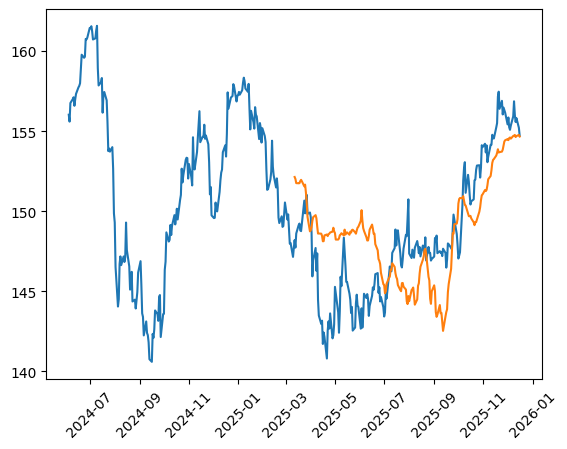

In [23]:
import matplotlib.pyplot as plt

# Flip data as it flips back again for some reason
usdYen_raw_data = np.flip(usdYen_raw_data, axis=0)

# Full data
plt.plot(usdYen_raw_data_dates, usdYen_raw_data)
plt.plot(usdYen_raw_data_dates[:200], keras_predictions_loaded_model_with_test_data)
plt.show()

# Zoom in on data
fig, ax = plt.subplots()
plt.plot(usdYen_raw_data_dates[:400], usdYen_raw_data[:400])
plt.plot(usdYen_raw_data_dates[:200], keras_predictions_loaded_model_with_test_data)
ax.tick_params("x", rotation=45)
plt.show()

## About the code

The Genetic Algorithm code is based on the code shown in the docs of the PyGAD library.

The timeseries data code is based on the code shown in the chapter of the book Deep Learning with Python.

## References

1- Francois Chollet. 2021. Deep Learning with Python, Second Edition. Chapter 10, Deep learning for timeseries. Manning Publications.

2- PyGAD. pygad.kerasga Module. Retrieved from https://pygad.readthedocs.io/en/latest/kerasga.html#